# Powerup Simulation Analysis

This notebook runs the simulation logic defined in `simulate_powerups.py` and visualizes the results with 95% Confidence Intervals.


In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add current directory to path to import script
sys.path.append(os.getcwd())

from simulate_powerups import (
    run_simulation,
    ProceduralStrategy,
    BenchmarkStrategy,
    AdaptiveStrategy,
)

# Set Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Run the Simulation
print("Running Simulation... (This may take a moment)")
players, strategies = run_simulation(return_data=True)
print(f"Simulation Complete. Processed {len(players)} players.")

Running Simulation... (This may take a moment)
Starting simulation for 100 days...
Simulation Complete. Processed 581 players.


In [3]:
# Build DataFrame
data = []

# Calculate Benchmark Mean for Ratio
benchmark_scores = [
    p.score for pid, p in players.items() if strategies[pid].name == "Benchmark"
]
benchmark_mean = (
    sum(benchmark_scores) / len(benchmark_scores) if benchmark_scores else 1
)

for pid, p in players.items():
    strat = strategies[pid]

    row = {
        "Name": p.name,
        "Score": p.score,
        "Score Ratio": p.score / benchmark_mean,
        "Streak": p.answer_streak,
        "Strategy Type": strat.name,
    }

    # Extract Dimensions
    if isinstance(strat, ProceduralStrategy):
        row["Core Strategy"] = strat.core_strategy
        row["Speed"] = strat.speed
        row["Correctness"] = strat.correctness
        row["Aggression"] = strat.aggression
    elif isinstance(strat, BenchmarkStrategy):
        row["Core Strategy"] = "Benchmark"
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"
    else:
        # Fallback
        row["Core Strategy"] = strat.name
        row["Speed"] = "N/A"
        row["Correctness"] = "N/A"
        row["Aggression"] = "N/A"

    data.append(row)

df = pd.DataFrame(data)
df.head()

,Name,Score,Score Ratio,Streak,Strategy Type,Core Strategy,Speed,Correctness,Aggression
0,Benchmark_1,13875,0.999514,90,Benchmark,Benchmark,N/A,N/A,N/A
1,Benchmark_2,14710,1.059665,95,Benchmark,Benchmark,N/A,N/A,N/A
2,Benchmark_3,12955,0.933240,84,Benchmark,Benchmark,N/A,N/A,N/A
3,Benchmark_4,14040,1.011400,91,Benchmark,Benchmark,N/A,N/A,N/A
4,Benchmark_5,13575,0.977903,88,Benchmark,Benchmark,N/A,N/A,N/A


In [4]:
def get_rank_palette(df, cat_col, val_col="Score Ratio"):
    """
    Returns a palette dictionary where:
    1st (highest mean) -> Gold
    2nd -> Silver
    3rd -> Bronze
    Others -> Blue/Gray
    """
    # Calculate means to determine rank
    means = df.groupby(cat_col)[val_col].mean().sort_values(ascending=False)
    ranks = means.index.tolist()

    palette = {}
    # Gold, Silver, Bronze
    medal_colors = {0: "#FFD700", 1: "#C0C0C0", 2: "#CD7F32"}
    default_color = "#5975A4"  # Muted Blue

    for i, cat in enumerate(ranks):
        palette[cat] = medal_colors.get(i, default_color)

    return palette


def add_bar_labels(ax, fmt="%.3f"):
    """Adds labels inside the bars in a bar plot."""
    # Annotate each bar container
    for container in ax.containers:
        # Use negative padding to place inside the bar
        # Depending on bar lightness, color might need adjustment, but black is usually safe for these colors
        ax.bar_label(container, fmt=fmt, label_type="edge", padding=-50)

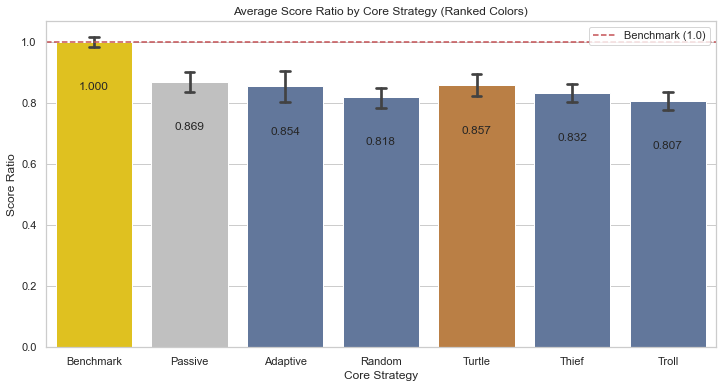

In [5]:
# Core Strategy Performance
plt.figure(figsize=(12, 6))

# Define palette based on rank (Gold, Silver, Bronze...)
palette = get_rank_palette(df, "Core Strategy", "Score Ratio")

# NOTE: Changed errorbar=('ci', 95) to ci=95 for compatibility with older seaborn versions
# Using Score Ratio
ax = sns.barplot(
    data=df, x="Core Strategy", y="Score Ratio", ci=95, capsize=0.1, palette=palette
)

# Add Labels
add_bar_labels(ax, fmt="%.3f")

plt.title("Average Score Ratio by Core Strategy (Ranked Colors)")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark (1.0)")
plt.legend()
plt.show()

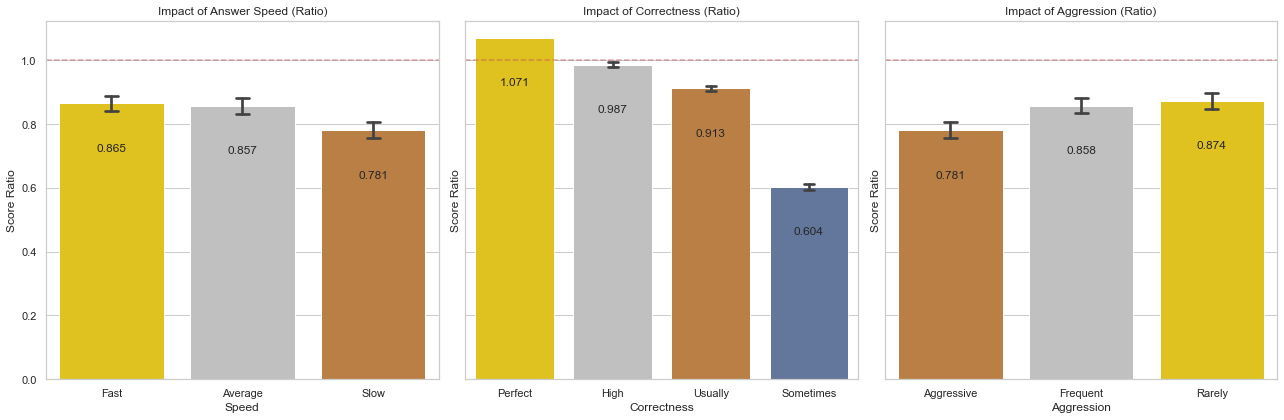

In [6]:
# Dimensional Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Remove Benchmark/NA for clean dimensional plots
# Keep only procedural (exclude Benchmark which has N/A dimensions)
dim_df = df[df["Speed"] != "N/A"]

# Order specifics
speed_order = ["Fast", "Average", "Slow"]
acc_order = ["Perfect", "High", "Usually", "Sometimes"]
# Note: "Passive" core strategy has "Rarely" aggression, but some might be "Aggressive" if defined so.
agg_order = ["Aggressive", "Frequent", "Rarely"]

# Generate palettes relative to the filtered data (dim_df)
speed_pal = get_rank_palette(dim_df, "Speed", "Score Ratio")
acc_pal = get_rank_palette(dim_df, "Correctness", "Score Ratio")
agg_pal = get_rank_palette(dim_df, "Aggression", "Score Ratio")

# NOTE: Using ci=95 instead of errorbar for compatibility
sns.barplot(
    ax=axes[0],
    data=dim_df,
    x="Speed",
    y="Score Ratio",
    order=speed_order,
    ci=95,
    capsize=0.1,
    palette=speed_pal,
)
axes[0].set_title("Impact of Answer Speed (Ratio)")
add_bar_labels(axes[0], fmt="%.3f")

sns.barplot(
    ax=axes[1],
    data=dim_df,
    x="Correctness",
    y="Score Ratio",
    order=acc_order,
    ci=95,
    capsize=0.1,
    palette=acc_pal,
)
axes[1].set_title("Impact of Correctness (Ratio)")
add_bar_labels(axes[1], fmt="%.3f")

sns.barplot(
    ax=axes[2],
    data=dim_df,
    x="Aggression",
    y="Score Ratio",
    order=agg_order,
    ci=95,
    capsize=0.1,
    palette=agg_pal,
)
axes[2].set_title("Impact of Aggression (Ratio)")
add_bar_labels(axes[2], fmt="%.3f")

# Add Benchmark Line to all (Ratio = 1.0)
for ax in axes:
    ax.axhline(1.0, color="r", linestyle="--", alpha=0.5, label="Benchmark")

plt.tight_layout()
plt.show()

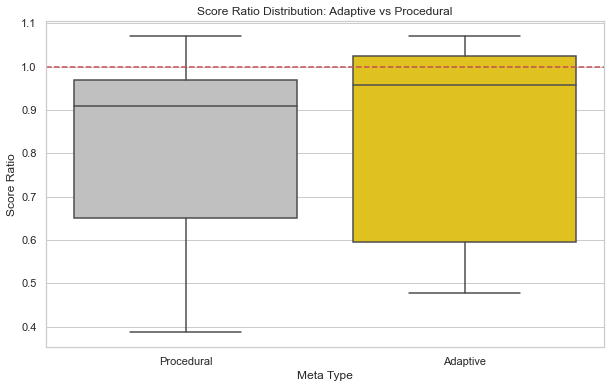

                       count      mean  std       min       25%       50%  \
Name                                                                        
Adaptive_Desperate_1     1.0  0.532354  NaN  0.532354  0.532354  0.532354   
Adaptive_Desperate_10    1.0  0.568012  NaN  0.568012  0.568012  0.568012   
Adaptive_Desperate_11    1.0  0.559728  NaN  0.559728  0.559728  0.559728   
Adaptive_Desperate_12    1.0  0.576656  NaN  0.576656  0.576656  0.576656   
Adaptive_Desperate_13    1.0  0.543159  NaN  0.543159  0.543159  0.543159   
Adaptive_Desperate_14    1.0  0.630324  NaN  0.630324  0.630324  0.630324   
Adaptive_Desperate_15    1.0  0.572694  NaN  0.572694  0.572694  0.572694   
Adaptive_Desperate_16    1.0  0.583140  NaN  0.583140  0.583140  0.583140   
Adaptive_Desperate_17    1.0  0.564050  NaN  0.564050  0.564050  0.564050   
Adaptive_Desperate_18    1.0  0.604391  NaN  0.604391  0.604391  0.604391   
Adaptive_Desperate_19    1.0  0.593945  NaN  0.593945  0.593945  0.593945   

In [7]:
# Adaptive vs Procedural
# Is Adaptive better than the sum of its parts?
plt.figure(figsize=(10, 6))

comparison_df = df[
    df["Strategy Type"].str.contains("Adaptive|Passive|Thief|Troll|Turtle|Random")
].copy()
comparison_df["Meta Type"] = comparison_df["Strategy Type"].apply(
    lambda x: "Adaptive" if "Adaptive" in x else "Procedural"
)

# Custom palette for just two items doesn't need bronze, but consistent with rank
meta_pal = get_rank_palette(comparison_df, "Meta Type", "Score Ratio")

sns.boxplot(data=comparison_df, x="Meta Type", y="Score Ratio", palette=meta_pal)
plt.title("Score Ratio Distribution: Adaptive vs Procedural")
plt.axhline(1.0, color="r", linestyle="--", label="Benchmark")
plt.show()

# Detailed Adaptive View
print(df[df["Strategy Type"] == "Adaptive"].groupby("Name")["Score Ratio"].describe())

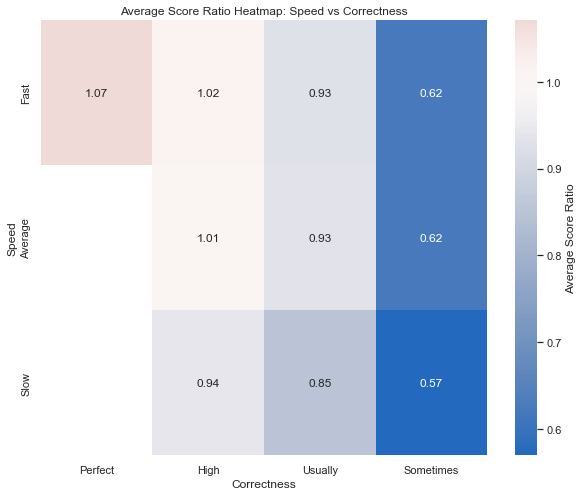

In [8]:
# Heatmap: Speed vs Correctness (Average Score Ratio)
# Filter for procedural only
proc_df = df[df["Speed"] != "N/A"]

heatmap_data = proc_df.pivot_table(
    index="Speed", columns="Correctness", values="Score Ratio", aggfunc="mean"
)

# Reorder indices for better readability
speed_order = ["Fast", "Average", "Slow"]
acc_order = ["Perfect", "High", "Usually", "Sometimes"]
# Filter to existing
speed_order = [s for s in speed_order if s in heatmap_data.index]
acc_order = [a for a in acc_order if a in heatmap_data.columns]

heatmap_data = heatmap_data.reindex(index=speed_order, columns=acc_order)

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",  # Changed to 2 decimal places for ratio
    cmap="vlag",  # Diverging palette
    center=1.0,  # Center color map at Benchmark (1.0)
    cbar_kws={"label": "Average Score Ratio"},
)
plt.title("Average Score Ratio Heatmap: Speed vs Correctness")
plt.show()

Top 15 Performing Players:
                   Name  Score  Score Ratio  Streak Core Strategy    Speed  \
20       Perfect_Player  14865     1.070830     100       Passive     Fast   
37   Adaptive_Expert_17  14860     1.070470     100      Adaptive     Fast   
33   Adaptive_Expert_13  14860     1.070470     100      Adaptive     Fast   
12         Benchmark_13  14845     1.069390      96     Benchmark      N/A   
30   Adaptive_Expert_10  14785     1.065067     100      Adaptive     Fast   
360      Turtle_AHR_280  14780     1.064707     100        Turtle  Average   
185     Passive_FHF_105  14770     1.063987     100       Passive     Fast   
339      Random_AHR_259  14760     1.063267       2        Random  Average   
1           Benchmark_2  14710     1.059665      95     Benchmark      N/A   
153      Passive_AHF_73  14695     1.058584      99       Passive  Average   
23    Adaptive_Expert_3  14670     1.056783     100      Adaptive     Fast   
401      Random_AHR_321  14670     1.

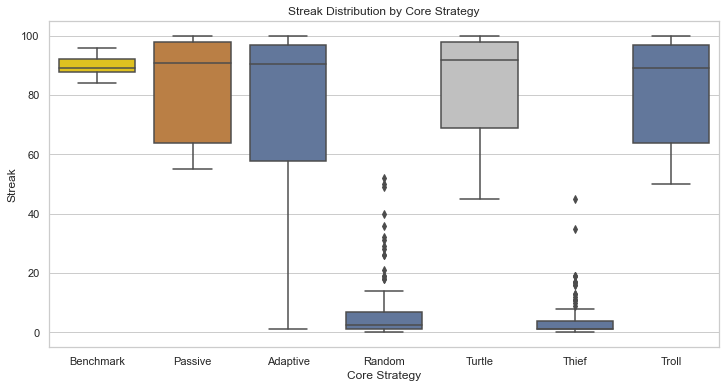

In [9]:
# Top Performers Analysis
# Group by Name/Config to see which specific combinations win most often across simulation runs (if multiple runs)
# Since we have one run with many players, we just look at the top individual players
top_performers = df.sort_values("Score", ascending=False).head(15)

print("Top 15 Performing Players:")
display_cols = [
    "Name",
    "Score",
    "Score Ratio",  # Added Ratio
    "Streak",
    "Core Strategy",
    "Speed",
    "Correctness",
    "Aggression",
]
# Only show columns that exist (e.g. if Benchmark is top)
print(top_performers[display_cols])

# Visualize Streak Distribution by Core Strategy
plt.figure(figsize=(12, 6))
streak_pal = get_rank_palette(df, "Core Strategy", "Streak")  # Rank by Streak this time
sns.boxplot(data=df, x="Core Strategy", y="Streak", palette=streak_pal)
plt.title("Streak Distribution by Core Strategy")
plt.show()